In [1]:
#@title Run this code to get started
import os

# Check and download exoTrain.csv
if not os.path.exists('exoTrain.csv'):
    print("Downloading exoTrain.csv...")
    !wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Planet%20Hunters/exoTrain.csv'
else:
    print("exoTrain.csv already exists")

# Check and download exoTest.csv
if not os.path.exists('exoTest.csv'):
    print("Downloading exoTest.csv...")
    !wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Planet%20Hunters/exoTest.csv'
else:
    print("exoTest.csv already exists")

from urllib.request import urlretrieve
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn import  metrics
from sklearn import tree
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from scipy.signal import savgol_filter
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay,precision_score,recall_score,f1_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, normalize

import warnings
warnings.filterwarnings('ignore')

def analyze_results(model, X_train, y_train, X_test, y_test):
    """
    Helper function to help interpret and model performance.

    Args:
    model: estimator instance
    X_train: {array-like, sparse matrix} of shape (n_samples, n_features)
    Input values for model training.
    y_train : array-like of shape (n_samples,)
    Target values for model training.
    X_test: {array-like, sparse matrix} of shape (n_samples, n_features)
    Input values for model testing.
    y_test : array-like of shape (n_samples,)
    Target values for model testing.

    Returns:
    None
    """
    print("-------------------------------------------")
    print("Model Results")
    print("")
    print("Training:")
    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train)
    plt.show()
    print("Testing:")
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

def check_norm_answers(v1, v2, v3, v4):
  print("Value 1:", v1 == 0.14)
  print("Value 2:", v2 == 0)
  print("Value 3:", v3 == 0.86)
  print("Value 4:", v4 == 1.0)

df_train = pd.read_csv('exoTrain.csv')
df_train['LABEL'] = df_train['LABEL'] - 1
df_test = pd.read_csv('exoTest.csv')
df_test['LABEL'] = df_test['LABEL'] - 1

exoTrain.csv        100%[===================>] 250.08M   230MB/s    in 1.1s    
exoTest.csv         100%[===================>]  27.57M   178MB/s    in 0.2s    


In [2]:
# Visualizing Data

print(len(df_train))
print(len(df_test))

df_train.head()

5087
570


,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,1,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,1,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,1,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,1,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,1,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


**Discuss**: What do the columns represent?

In [3]:
df_train


,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,1,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,1,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,1,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,1,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,1,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,0,-91.91,-92.97,-78.76,-97.33,-68.00,-68.24,-75.48,-49.25,-30.92,...,139.95,147.26,156.95,155.64,156.36,151.75,-24.45,-17.00,3.23,19.28
5083,0,989.75,891.01,908.53,851.83,755.11,615.78,595.77,458.87,492.84,...,-26.50,-4.84,-76.30,-37.84,-153.83,-136.16,38.03,100.28,-45.64,35.58
5084,0,273.39,278.00,261.73,236.99,280.73,264.90,252.92,254.88,237.60,...,-26.82,-53.89,-48.71,30.99,15.96,-3.47,65.73,88.42,79.07,79.43
5085,0,3.82,2.09,-3.29,-2.88,1.66,-0.75,3.85,-0.03,3.28,...,10.86,-3.23,-5.10,-4.61,-9.82,-1.50,-4.65,-14.55,-6.41,-2.55


#### Comparing Flux Curves for Exoplanets vs. Non-Exoplanets

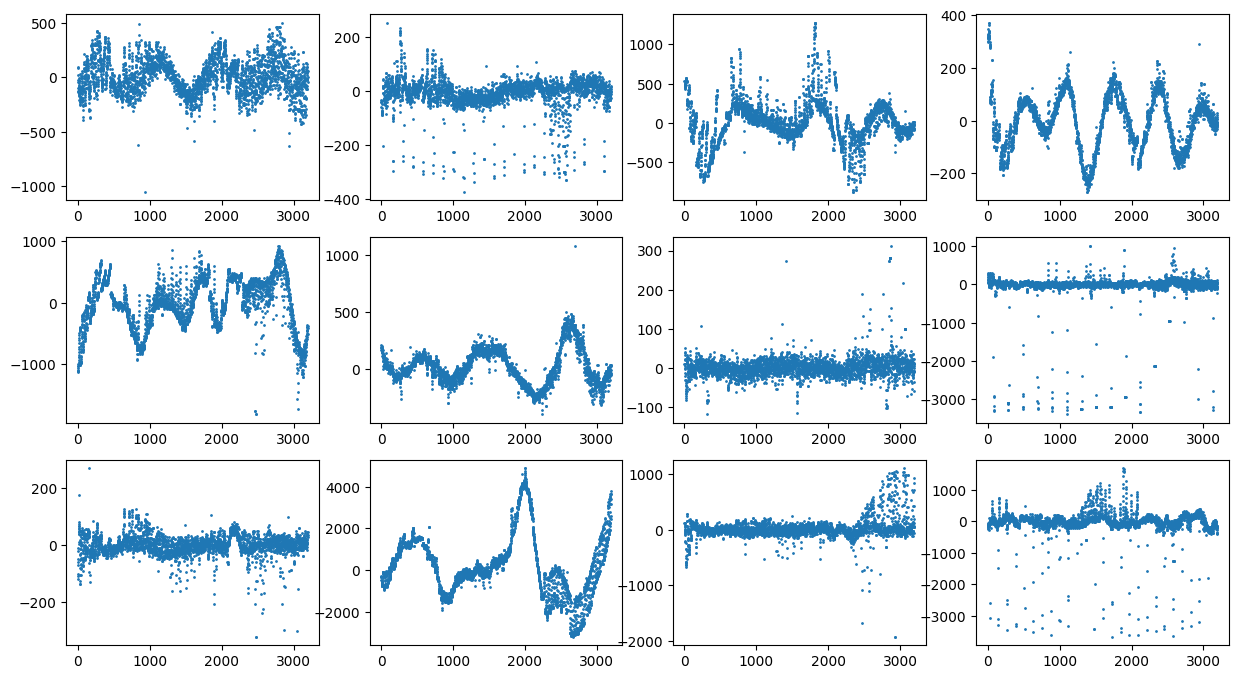

In [4]:
#@title Run to see samples of exoplanet stars
fig = plt.figure(figsize=(15,40))
for i in range(12):
    ax = fig.add_subplot(14,4,i+1)
    ax.scatter(np.arange(3197),df_train[df_train['LABEL'] == 1].iloc[i,1:],s=1)

And now let's review what *non*-exoplanet stars look like! What patterns do you notice in these examples from the training set?

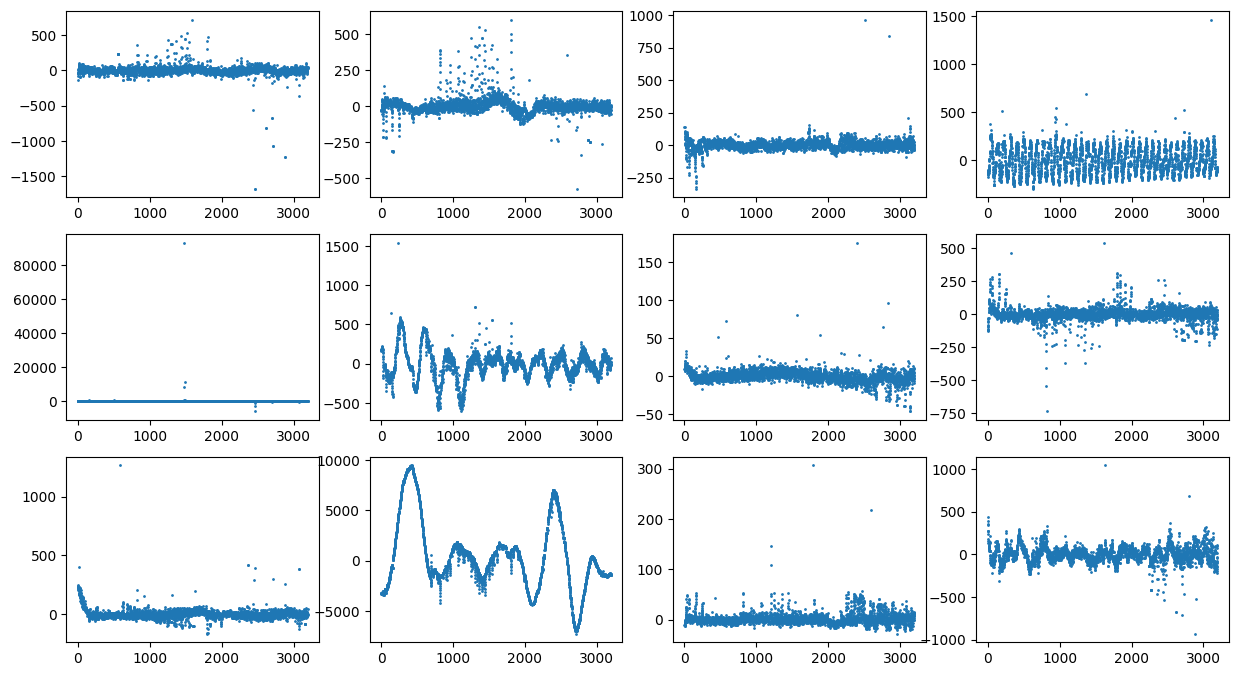

In [5]:
#@title Run to see samples of non-exoplanet stars
fig = plt.figure(figsize=(15,40))
for i in range(12):
    ax = fig.add_subplot(14,4,i+1)
    ax.scatter(np.arange(3197),df_train[df_train['LABEL']==0].iloc[i,1:],s=1)

Checking Difference between Exoplanets and Non Exoplanets

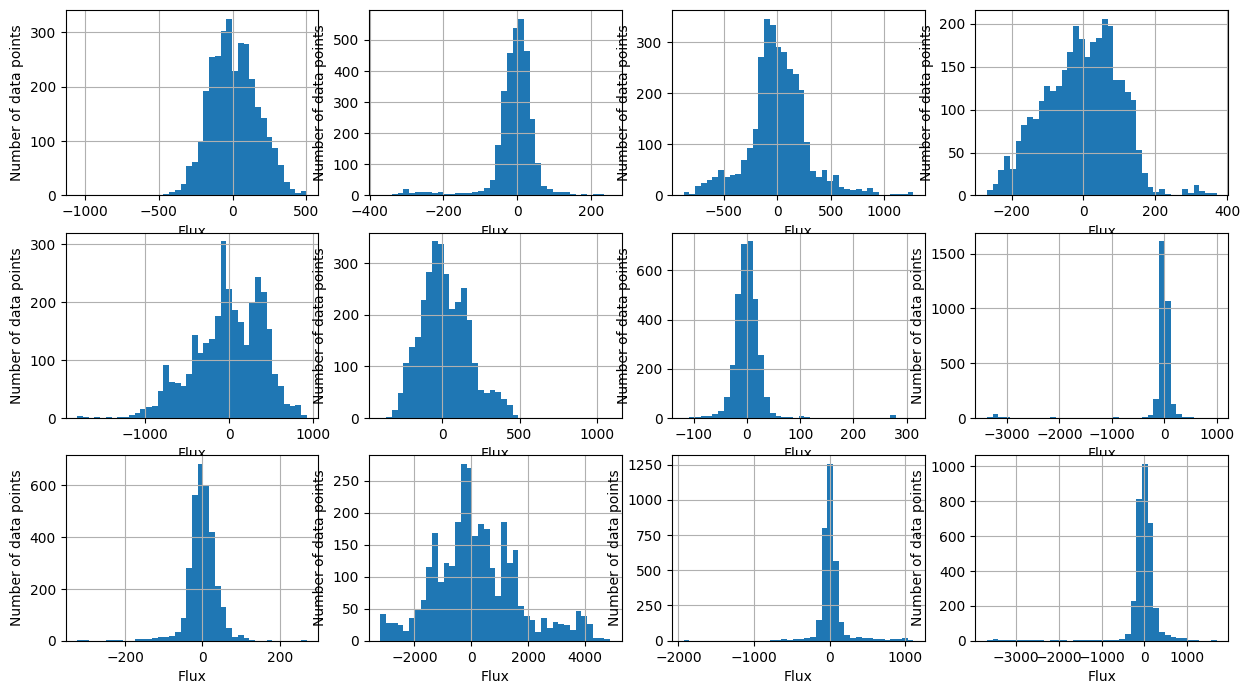

In [6]:
#@title Run to see histograms of exoplanet stars
fig = plt.figure(figsize=(15,40))
for i in range(12):
    ax = fig.add_subplot(14,4,i+1)
    plt.xlabel("Flux")
    plt.ylabel("Number of data points")
    df_train[df_train['LABEL']==1].iloc[i,1:].hist(bins=40)

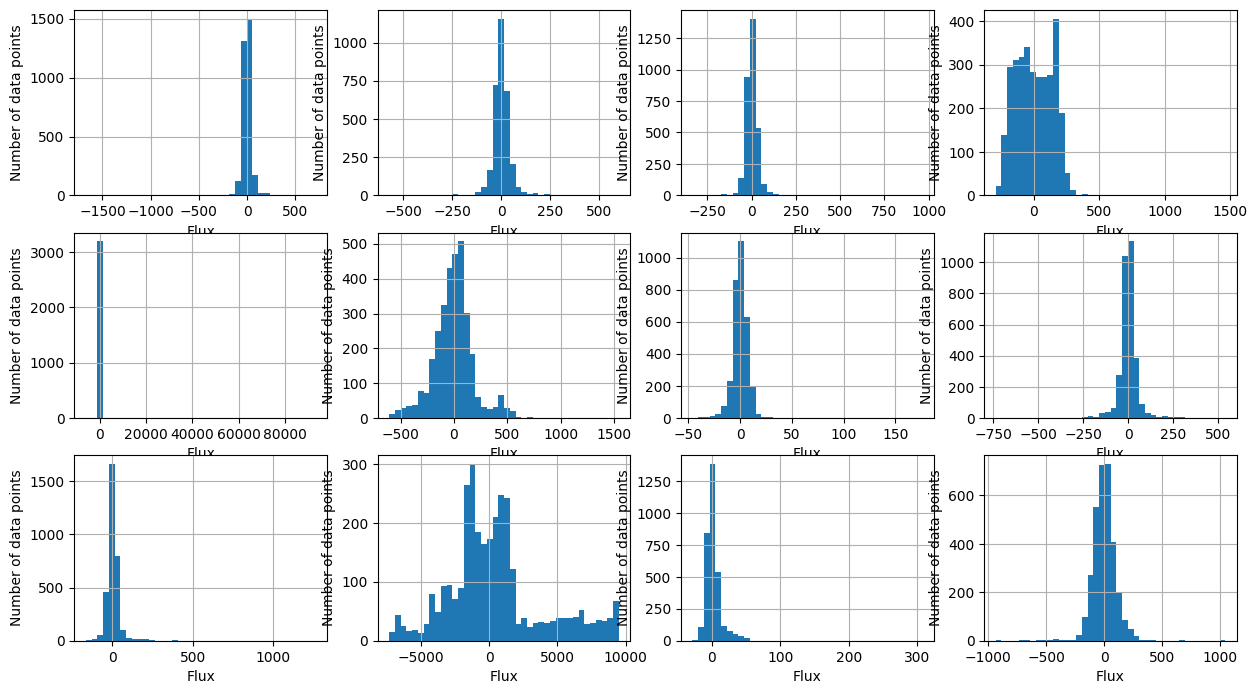

In [7]:
#@title Run to see histograms of non-exoplanet stars
fig = plt.figure(figsize=(15,40))
for i in range(12):
    ax = fig.add_subplot(14,4,i+1)
    plt.xlabel("Flux")
    plt.ylabel("Number of data points")
    df_train[df_train['LABEL']==0].iloc[i,1:].hist(bins=40)

### Counting Exoplanets

In `df_train`, how many samples are from an exoplanet star? How many are non-exoplanet-stars? How about in `df_test`?

As in Notebook 1, please use [`.loc`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html) to separate out the data frames, and then `len` to print out the length of each.

In [8]:
### YOUR CODE HERE
label_train = df_train["LABEL"]
label_test = df_test["LABEL"]


exo_train = df_train.loc[label_train==1]
non_exo_train = df_train.loc[label_train==0]

exo_test = df_test.loc[label_test==1]
non_exo_test = df_test.loc[label_test==0]

print(len(exo_train))
print(len(non_exo_train))

print(len(exo_test))
print(len(non_exo_test))


37
5050
5
565


Calculating

In [9]:
### YOUR CODE HERE

portion_train = len(exo_train)/len(df_train)
print(portion_train)

portion_test = len(exo_test)/len(df_test)
print(portion_test)

0.007273442107332416
0.008771929824561403


**Trying KNN**

In [10]:
X_train = df_train.drop('LABEL', axis=1)
y_train = df_train['LABEL']

X_test = df_test.drop('LABEL', axis=1)
y_test = df_test['LABEL']

#### Step 1: Create our model

Let's start by using a `KNeighborsClassifier` model, which has already been imported from [Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

In [11]:
# Create a KNN model (will train later)

n_neighbors = 1

model = KNeighborsClassifier(n_neighbors)


#### Step 2: Train our model

Now train the KNN model defined on `X_train` and `y_train` using the `fit` method.

In [12]:
# Train the model

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

#### Step 3: Predictions and Accuracy

Now calculate the `train_predictions` and `test_predictions` using the `predict` function from our model. Then print out the results from using `accuracy_score`, previously imported from `sklearn.metrics`. This may take a while to run!

In [13]:
# Calculate the predictions and accuracies on X_train and X_test
# using our trained model
trainpred = model.predict(X_train)
print(accuracy_score(y_train, trainpred))

testpred = model.predict(X_test)
accuracy_score(y_test, testpred)


1.0


0.9912280701754386

Using Confusion Matrices

-------------------------------------------
Model Results

Training:


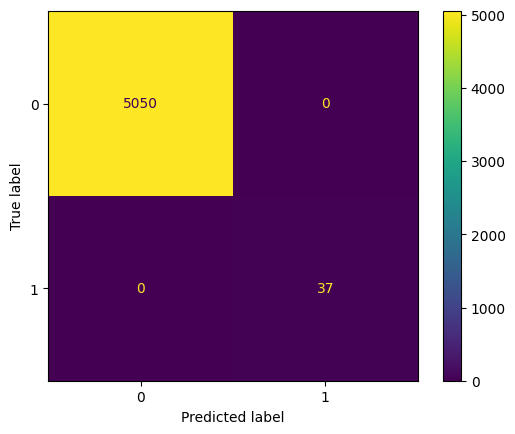

Testing:


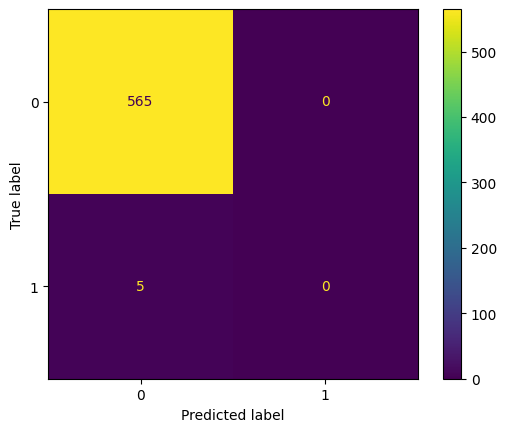

In [14]:
analyze_results(model, X_train, y_train, X_test, y_test)

## Milestone 3: Logistic Regression

You might feel less confident in your KNN model after seeing the confusion matrix! Let's try out some other models.


Here, let's do what we did before, but using a Logistic Regression model instead of a KNN model! Please set up a model using the imported `LogisticRegression` object with `max_iter`=1000.

In [15]:
# Create a Logistic Regression model (will train later)

max_iter = 1000

model2 = LogisticRegression(max_iter=1000)

Repeating what we did for KNN

In [16]:
model2.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

0.9197955573029291
0.6385964912280702
-------------------------------------------
Model Results

Training:


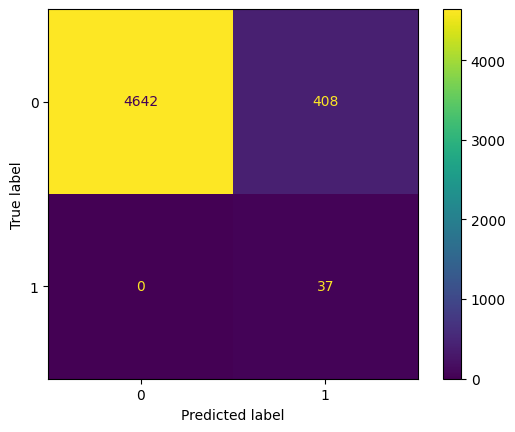

Testing:


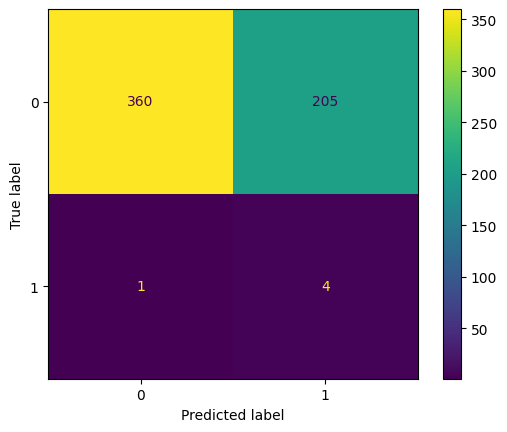

In [17]:
trainpred2 = model2.predict(X_train)
print(accuracy_score(y_train, trainpred2))

preds = model2.predict(X_test)
print(accuracy_score(y_test, preds))

analyze_results(model2, X_train, y_train, X_test, y_test)

In [18]:
#@title Run to define helper functions
# Helper functions that we can run for the three augmentation functions that will be used, but not explroed in depth

def smote(a,b):
    model = SMOTE()
    X,y = model.fit_resample(a, b)
    return X,y

def savgol(df1,df2):
    x = savgol_filter(df1,21,4,deriv=0)
    y = savgol_filter(df2,21,4,deriv=0)
    return x,y

def fourier(df1,df2):
    X_train = np.abs(np.fft.fft(df1, axis=1))
    X_test = np.abs(np.fft.fft(df2, axis=1))
    return X_train,X_test

def norm(df1,df2):
    X_train = normalize(df1)
    X_test = normalize(df2)
    return X_train,X_test

def robust(df1,df2):
    scaler = RobustScaler()
    X_train = scaler.fit_transform(df1)
    X_test = scaler.transform(df2)
    return X_train,X_test

In [19]:
def norm(df1,df2):
    X_train = normalize(df1)
    X_test = normalize(df2)
    return X_train,X_test

In [20]:
fourier_X_train, fourier_X_test = fourier(X_train, X_test)
savgol_X_train, savgol_X_test = savgol(fourier_X_train, fourier_X_test)

#####TODO#########
norm_X_train, norm_X_test = norm(savgol_X_train, savgol_X_test)
##################

robust_X_train, robust_X_test = robust(norm_X_train, norm_X_test)

In [21]:
smote_X_train, smote_y_train = smote(robust_X_train, y_train)

Visualizing Augmented Data

In [22]:
#@title Run to load helper functions and variables
def visualize_data(X, y, indices):
  stars = indices

  fig = plt.figure(figsize=(24,500))
  x = np.array(range(3197))
  for i in range(0, len(stars)):
      ax = fig.add_subplot(100, 5, 1+i)
      ax.set_title('Data ' + "I:" + str(stars[i]) + " Label:" + str(y[stars[i]]))
      ax.scatter(x, X[stars[i],:], s=1)

robust_y_train_with_exoplanet_indices = y_train.to_numpy().nonzero()[0]
robust_y_train_with_no_exoplanet_indices = (y_train - 1).to_numpy().nonzero()[0]

smote_y_train_with_exoplanet_indices = smote_y_train.to_numpy().nonzero()[0]
smote_y_train_with_no_exoplanet_indices = (smote_y_train - 1).to_numpy().nonzero()[0]

Orginal, newly modified data with exoplanets:


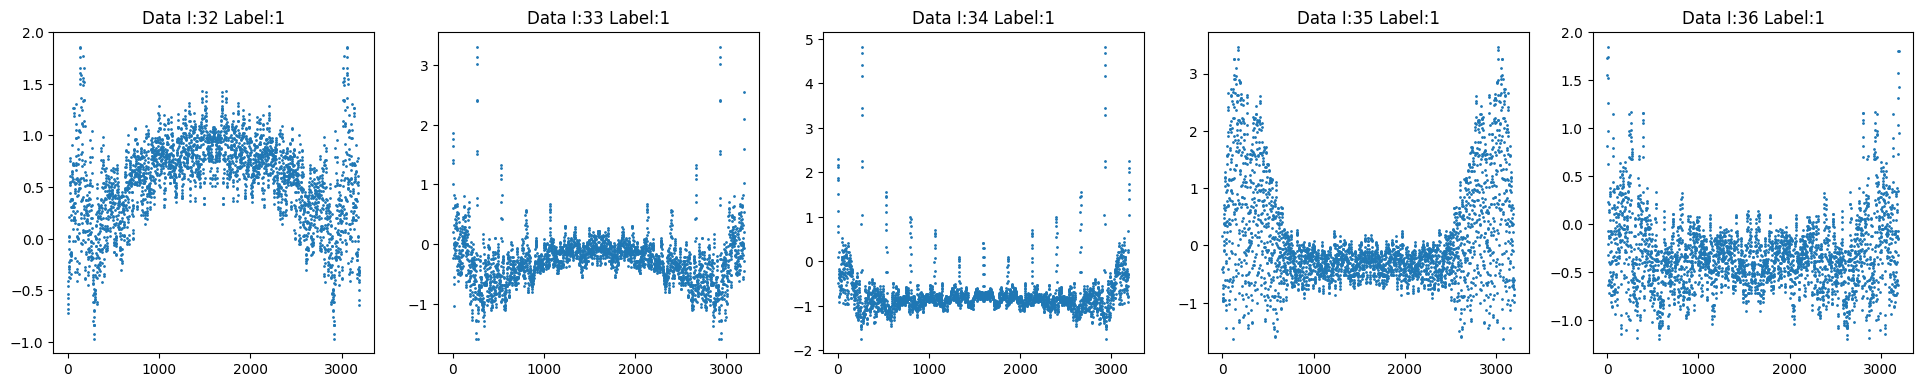

In [23]:
#@title Run to visualize original, preprocessed data with exoplanets
print("Orginal, newly modified data with exoplanets:")
visualize_data(robust_X_train, y_train, robust_y_train_with_exoplanet_indices[-5:])

Augmented data with Exoplanets:


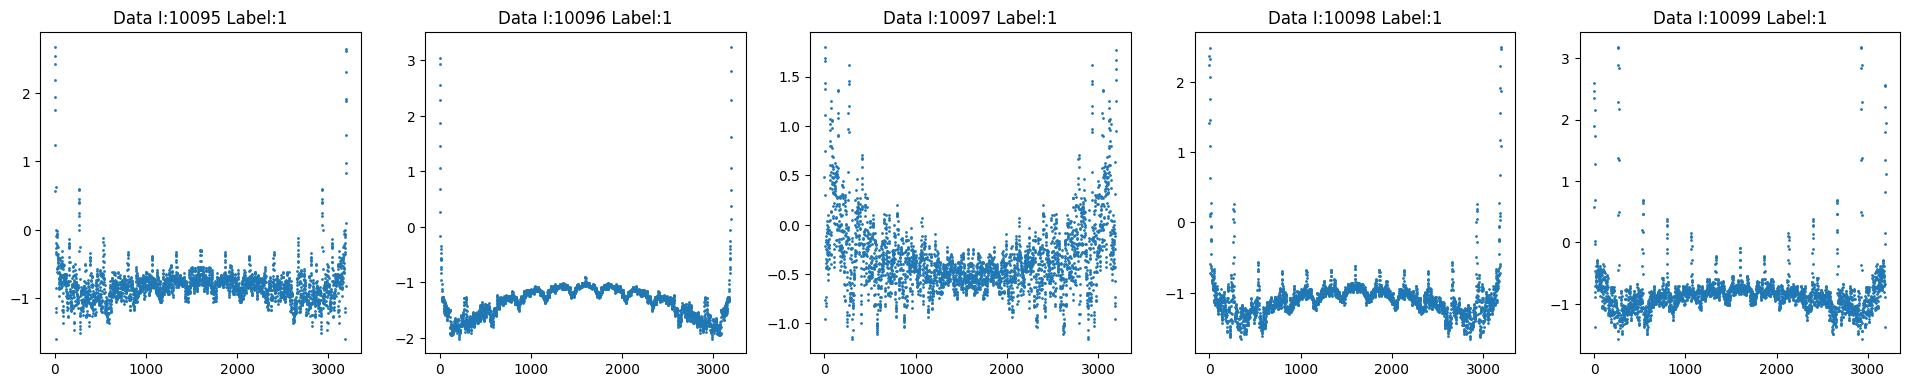

In [24]:
#@title Run to visualize newly generated data containing exoplanets
print("Augmented data with Exoplanets:")
visualize_data(smote_X_train, smote_y_train, smote_y_train_with_exoplanet_indices[-5:])

**Discuss: How do these plots compare to the plots without SMOTE? What's similar and different about them?**

Orginal, newly modified data with no exoplanets:


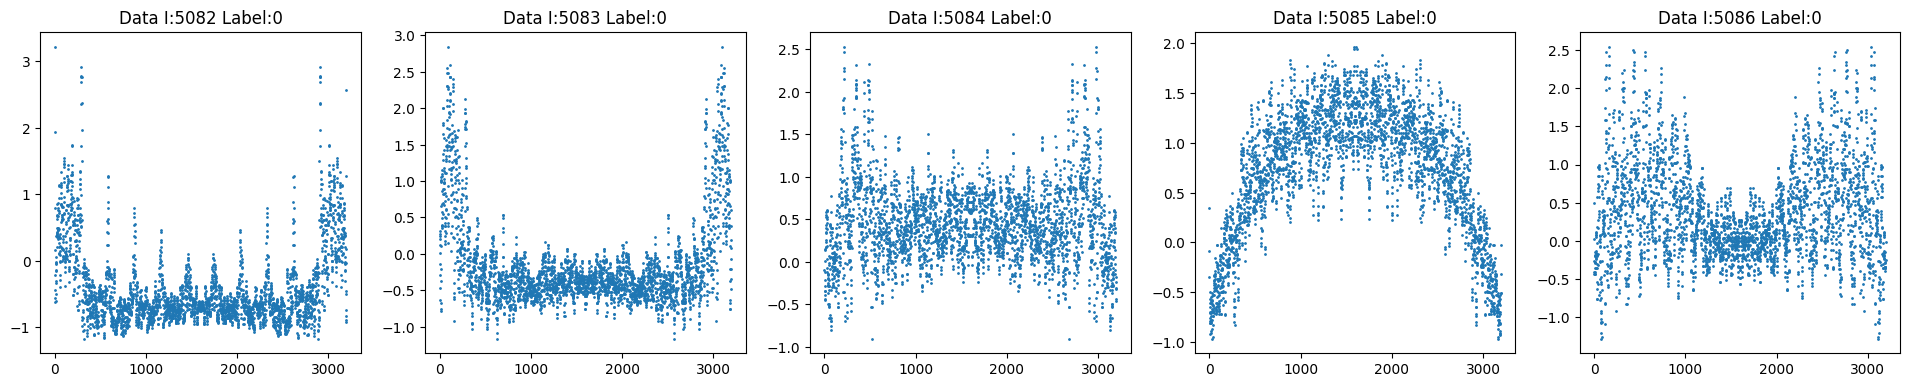

In [25]:
#@title Run to visualize original, modified data with no Exoplanets
print("Orginal, newly modified data with no exoplanets:")
visualize_data(robust_X_train, y_train, robust_y_train_with_no_exoplanet_indices[-5:])

Augmented data with no Exoplanets:


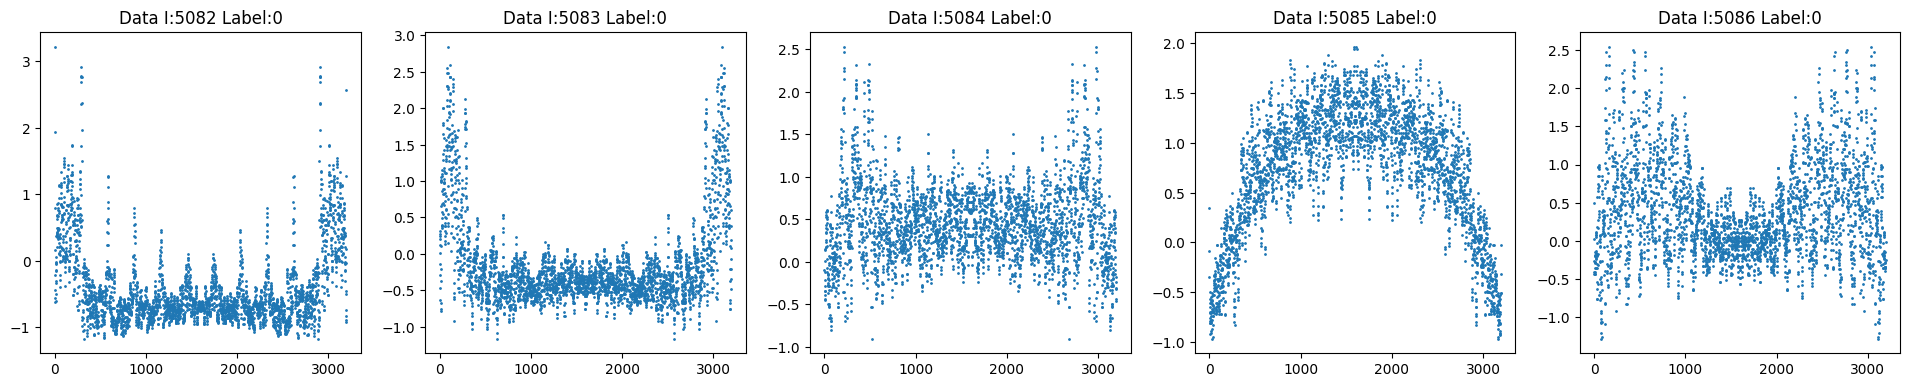

In [26]:
#@title Run to visualize newly generated data containing no exoplanets
print("Augmented data with no Exoplanets:")
visualize_data(smote_X_train, smote_y_train, smote_y_train_with_no_exoplanet_indices[-5:])

Checking the Accuracy with the Augmented Data


-------------------------------------------
Model Results

Training:


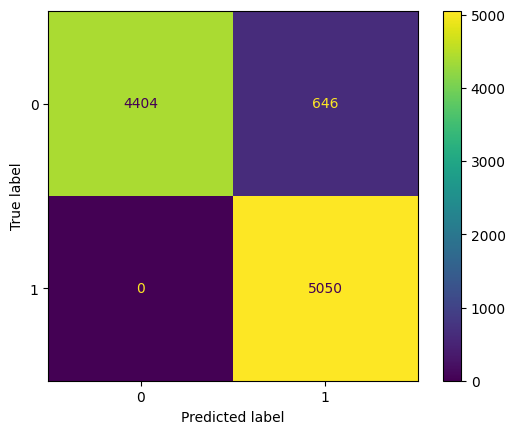

Testing:


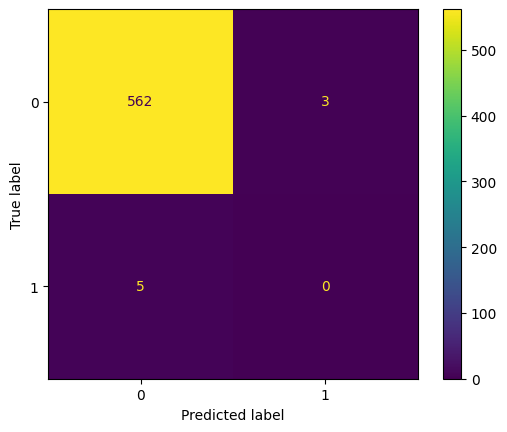

In [27]:
model = KNeighborsClassifier(n_neighbors=10)

model.fit(smote_X_train, smote_y_train)

preds = model.predict(X_test)

accuracy_score(y_test, preds)

analyze_results(model, smote_X_train, smote_y_train, X_test, y_test)

0.6280701754385964
-------------------------------------------
Model Results

Training:


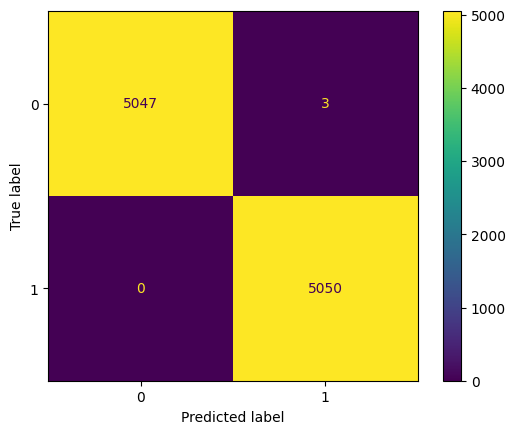

Testing:


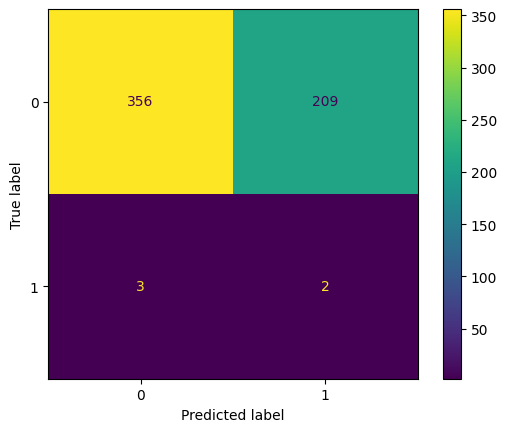

In [28]:
model = LogisticRegression(max_iter=1000)

model.fit(smote_X_train, smote_y_train)

preds = model.predict(X_test)

print(accuracy_score(y_test, preds))

analyze_results(model, smote_X_train, smote_y_train, X_test, y_test)

0.9
-------------------------------------------
Model Results

Training:


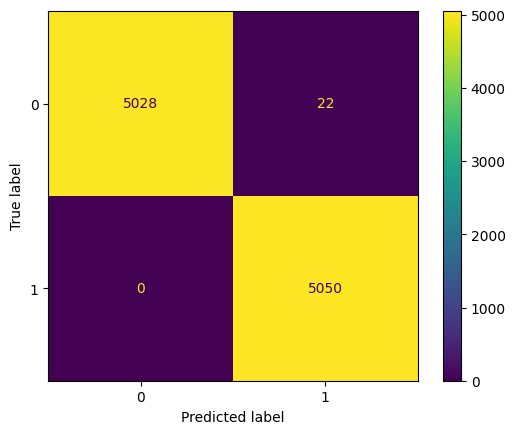

Testing:


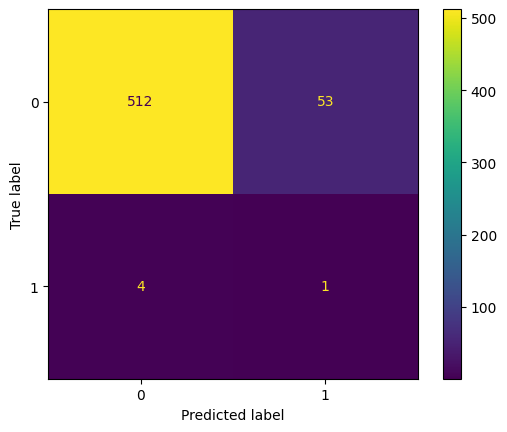

In [29]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(64, 32, 16), random_state=1)

model.fit(smote_X_train, smote_y_train)

preds = model.predict(X_test)

print(accuracy_score(y_test, preds))

analyze_results(model, smote_X_train, smote_y_train, X_test, y_test)